<a href="https://colab.research.google.com/github/naveedurrehman160-design/LocalRepo/blob/main/AI_Project(Brain_Tumor).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount DRive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data prep

In [ ]:
# ==============================
# STEP 1: MOUNT GOOGLE DRIVE
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# ==============================
# STEP 2: IMPORT LIBRARIES
# ==============================
import os
import shutil
from glob import glob
from sklearn.model_selection import train_test_split

# ==============================
# STEP 3: DEFINE PATHS
# ==============================
source_dir = "/content/drive/MyDrive/BrainTumor"
output_dir = "/content/drive/MyDrive/BrainTumor_flat"

train_dir = os.path.join(output_dir, "Train")
test_dir  = os.path.join(output_dir, "Test")

# ==============================
# STEP 4: CLEAN & CREATE FOLDERS
# ==============================
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(train_dir + "/Tumor")
os.makedirs(train_dir + "/No_Tumor")
os.makedirs(test_dir + "/Tumor")
os.makedirs(test_dir + "/No_Tumor")

# ==============================
# STEP 5: LOAD IMAGES
# ==============================
tumor_imgs = glob(os.path.join(source_dir, "yes", "*"))
no_tumor_imgs = glob(os.path.join(source_dir, "no", "*"))

print("Tumor images found:", len(tumor_imgs))
print("No Tumor images found:", len(no_tumor_imgs))

# ==============================
# STEP 6: TRAIN-TEST SPLIT (80/20)
# ==============================
train_t, test_t = train_test_split(
    tumor_imgs, test_size=0.2, random_state=42, shuffle=True
)

train_n, test_n = train_test_split(
    no_tumor_imgs, test_size=0.2, random_state=42, shuffle=True
)

# ==============================
# STEP 7: COPY FILES
# ==============================
for img in train_t:
    shutil.copy(img, train_dir + "/Tumor/")

for img in test_t:
    shutil.copy(img, test_dir + "/Tumor/")

for img in train_n:
    shutil.copy(img, train_dir + "/No_Tumor/")

for img in test_n:
    shutil.copy(img, test_dir + "/No_Tumor/")

# ==============================
# STEP 8: FINAL SUMMARY
# ==============================
print("\n✅ DATASET PREPARATION COMPLETE!")
print("Training Tumor images:", len(os.listdir(train_dir + "/Tumor")))
print("Training No Tumor images:", len(os.listdir(train_dir + "/No_Tumor")))
print("Testing Tumor images:", len(os.listdir(test_dir + "/Tumor")))
print("Testing No Tumor images:", len(os.listdir(test_dir + "/No_Tumor")))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tumor images found: 1500
No Tumor images found: 1500

✅ DATASET PREPARATION COMPLETE!
Training Tumor images: 1200
Training No Tumor images: 1200
Testing Tumor images: 300
Testing No Tumor images: 300


# Data Preprocessing

In [ ]:
# ==============================
# DATA PREPROCESSING & AUGMENTATION
# ==============================

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# ==============================
# DATASET PATHS
# ==============================
train_dir = "/content/drive/MyDrive/BrainTumor_flat/Train"
test_dir  = "/content/drive/MyDrive/BrainTumor_flat/Test"

print("Train directory exists:", os.path.exists(train_dir))
print("Test directory exists:", os.path.exists(test_dir))

# ==============================
# IMAGE PARAMETERS
# ==============================
img_size = (224, 224)
batch_size = 32

# ==============================
# TRAIN DATA AUGMENTATION
# ==============================
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    rotation_range=15,       # Small rotations
    width_shift_range=0.1,   # Horizontal shift
    height_shift_range=0.1,  # Vertical shift
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,    # Flip images
    fill_mode='nearest'
)

# ==============================
# TEST DATA (NO AUGMENTATION)
# ==============================
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ==============================
# LOAD TRAIN DATA
# ==============================
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# ==============================
# LOAD TEST DATA
# ==============================
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# CLASS INFORMATION
# ==============================
print("\nClass Indices:", train_generator.class_indices)


Train directory exists: True
Test directory exists: True
Found 2400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.

Class Indices: {'No_Tumor': 0, 'Tumor': 1}


Saving y4.jpg to y4.jpg


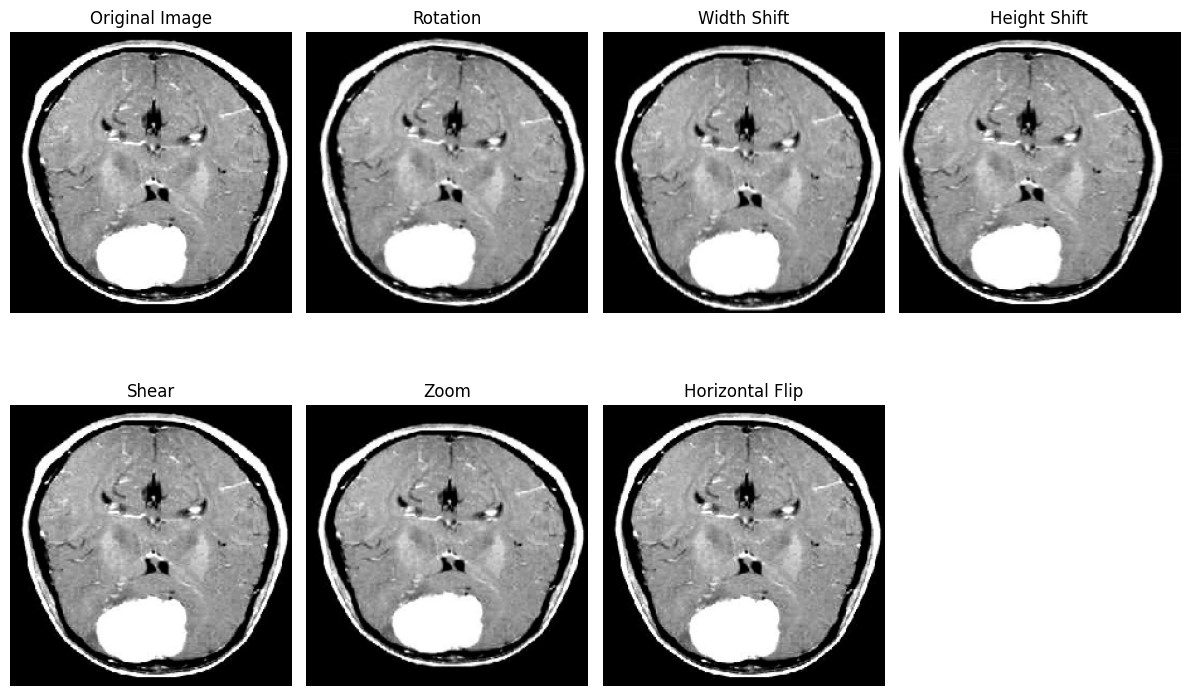

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# ============================
# UPLOAD IMAGE
# ============================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# ============================
# DEFINE AUGMENTATIONS
# ============================
augmentations = {
    "Rotation": ImageDataGenerator(rotation_range=15),
    "Width Shift": ImageDataGenerator(width_shift_range=0.1),
    "Height Shift": ImageDataGenerator(height_shift_range=0.1),
    "Shear": ImageDataGenerator(shear_range=0.05),
    "Zoom": ImageDataGenerator(zoom_range=0.1),
    "Horizontal Flip": ImageDataGenerator(horizontal_flip=True)
}

# ============================
# PLOT
# ============================
plt.figure(figsize=(12, 8))

# Original image
plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Apply each augmentation separately
i = 2
for name, gen in augmentations.items():
    aug_iter = gen.flow(img_array, batch_size=1)
    aug_img = next(aug_iter)[0]

    plt.subplot(2, 4, i)
    plt.imshow(aug_img)
    plt.title(name)
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

# CNN Model

In [ ]:
# ==============================
# CNN MODEL CREATION
# ==============================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# ==============================
# MODEL PARAMETERS
# ==============================
input_shape = (224, 224, 3)
num_classes = 2

# ==============================
# BUILD CNN MODEL
# ==============================
model = Sequential()

# -------- Block 1 --------
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

# -------- Block 2 --------
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

# -------- Block 3 --------
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

# ==============================
# FLATTEN & FULLY CONNECTED LAYERS
# ==============================
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# ==============================
# OUTPUT LAYER
# ==============================
model.add(Dense(num_classes, activation='softmax'))

# ==============================
# COMPILE MODEL
# ==============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# MODEL SUMMARY
# ==============================
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,010,530 (99.22 MB)

 Trainable params: 26,010,530 (99.22 MB)

 Non-trainable params: 0 (0.00 B)

# Data Transfer to local workspace and training

In [ ]:
# ==============================
# STEP 1: CHECK GPU
# ==============================
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# ==============================
# STEP 2: FIND DATASET IN DRIVE
# ==============================
import os
import shutil

possible_paths = [
    "/content/drive/MyDrive/BrainTumor_flat",
    "/content/drive/MyDrive/BrainTumor/BrainTumor_flat"
]

drive_dataset_path = None
for path in possible_paths:
    if os.path.exists(path):
        drive_dataset_path = path
        break

if drive_dataset_path is None:
    raise FileNotFoundError("❌ BrainTumor_flat folder not found in Drive")

print("✅ Dataset found at:", drive_dataset_path)

# ==============================
# STEP 3: COPY DATASET TO LOCAL COLAB
# ==============================
local_dataset_path = "/content/BrainTumor_flat"

if os.path.exists(local_dataset_path):
    shutil.rmtree(local_dataset_path)

shutil.copytree(drive_dataset_path, local_dataset_path)

print("✅ Dataset copied to local Colab")



GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Dataset found at: /content/drive/MyDrive/BrainTumor_flat
✅ Dataset copied to local Colab


In [ ]:
# ==============================
# STEP 4: IMPORT LIBRARIES
# ==============================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ==============================
# STEP 5: DATASET PATHS (LOCAL)
# ==============================
train_dir = "/content/BrainTumor_flat/Train"
test_dir  = "/content/BrainTumor_flat/Test"

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

# ==============================
# STEP 6: IMAGE PARAMETERS
# ==============================
img_size = (224, 224)
batch_size = 32

# ==============================
# STEP 7: DATA GENERATORS
# ==============================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# STEP 8: CALLBACKS
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/brain_tumor_cnn_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

# ==============================
# STEP 9: TRAIN MODEL
# ==============================
epochs = 25

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint]
)

print("✅ Training completed & model saved to Drive")


Train exists: True
Test exists: True
Found 2400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.5262 - loss: 0.7428

75/75 ━━━━━━━━━━━━━━━━━━━━ 58s 519ms/step - accuracy: 0.5264 - loss: 0.7422 - val_accuracy: 0.5000 - val_loss: 0.6808
Epoch 2/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.6174 - loss: 0.6546

75/75 ━━━━━━━━━━━━━━━━━━━━ 38s 503ms/step - accuracy: 0.6180 - loss: 0.6541 - val_accuracy: 0.7467 - val_loss: 0.5050
Epoch 3/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 37s 496ms/step - accuracy: 0.7158 - loss: 0.5714 - val_accuracy: 0.7017 - val_loss: 0.5396
Epoch 4/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.7406 - loss: 0.5369

...

75/75 ━━━━━━━━━━━━━━━━━━━━ 42s 561ms/step - accuracy: 0.7887 - loss: 0.4606 - val_accuracy: 0.8667 - val_loss: 0.3295
Epoch 12/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 38s 504ms/step - accuracy: 0.8090 - loss: 0.4230 - val_accuracy: 0.8283 - val_loss: 0.3983
Epoch 13/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 415ms/step - accuracy: 0.8296 - loss: 0.3953 - val_accuracy: 0.8383 - val_loss: 0.3660
Epoch 14/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 436ms/step - accuracy: 0.8438 - loss: 0.3761 - val_accuracy: 0.8600 - val_loss: 0.3341
Epoch 15/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 422ms/step - accuracy: 0.8262 - loss: 0.3880 - val_accuracy: 0.8650 - val_loss: 0.3073
Epoch 16/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8405 - loss: 0.3682

75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 464ms/step - accuracy: 0.8406 - loss: 0.3682 - val_accuracy: 0.8700 - val_loss: 0.2992
Epoch 17/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8460 - loss: 0.3669

75/75 ━━━━━━━━━━━━━━━━━━━━ 43s 576ms/step - accuracy: 0.8461 - loss: 0.3667 - val_accuracy: 0.8883 - val_loss: 0.2554
Epoch 18/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 37s 496ms/step - accuracy: 0.8482 - loss: 0.3336 - val_accuracy: 0.8800 - val_loss: 0.2698
Epoch 19/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 421ms/step - accuracy: 0.8560 - loss: 0.3420 - val_accuracy: 0.8833 - val_loss: 0.2794
Epoch 20/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8538 - loss: 0.3643

75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 467ms/step - accuracy: 0.8539 - loss: 0.3641 - val_accuracy: 0.8950 - val_loss: 0.2312
Epoch 21/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 44s 505ms/step - accuracy: 0.8870 - loss: 0.2899 - val_accuracy: 0.8883 - val_loss: 0.2475
Epoch 22/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 416ms/step - accuracy: 0.8803 - loss: 0.2914 - val_accuracy: 0.8900 - val_loss: 0.3068
Epoch 23/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 418ms/step - accuracy: 0.8915 - loss: 0.2757 - val_accuracy: 0.8817 - val_loss: 0.3171
Epoch 24/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 431ms/step - accuracy: 0.8875 - loss: 0.2650 - val_accuracy: 0.8883 - val_loss: 0.2609
Epoch 25/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8881 - loss: 0.2809

75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 474ms/step - accuracy: 0.8881 - loss: 0.2806 - val_accuracy: 0.9033 - val_loss: 0.2117
✅ Training completed & model saved to Drive


# Model Evaluation & Visualizations

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step
Accuracy : 0.9033333333333333
Precision: 0.8734567901234568
Recall   : 0.9433333333333334
F1-Score : 0.907051282051282


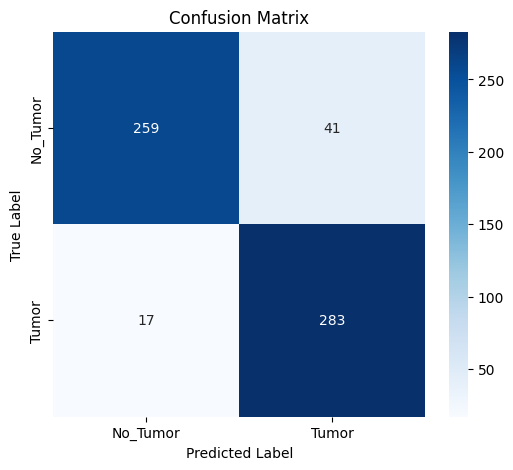


Classification Report:

              precision    recall  f1-score   support

    No_Tumor       0.94      0.86      0.90       300
       Tumor       0.87      0.94      0.91       300

    accuracy                           0.90       600
   macro avg       0.91      0.90      0.90       600
weighted avg       0.91      0.90      0.90       600



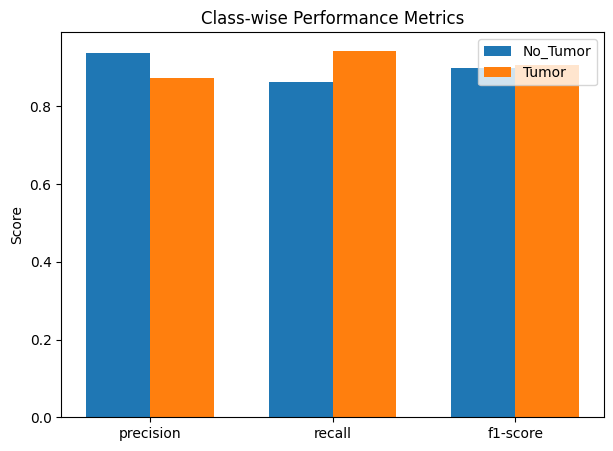

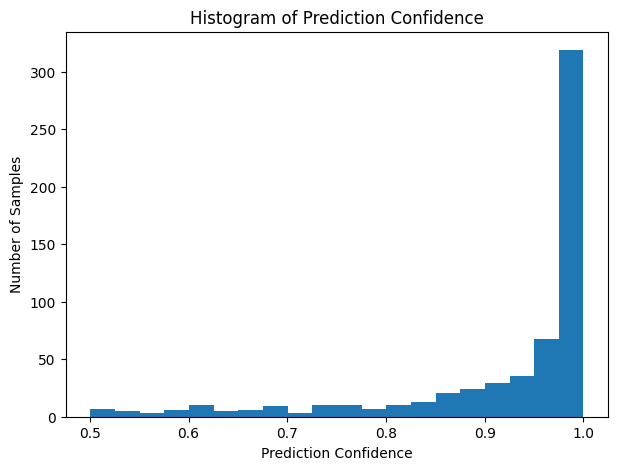

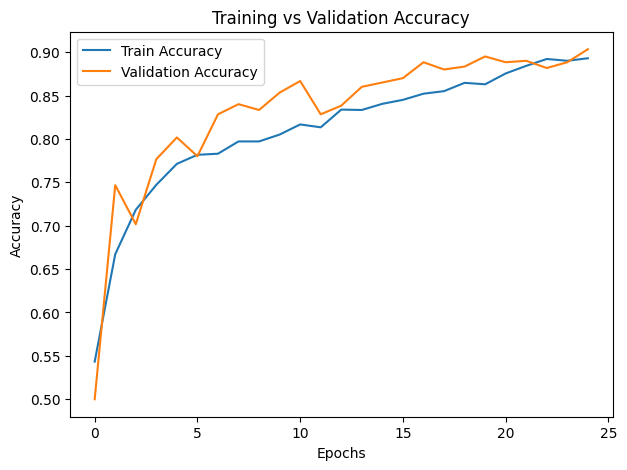

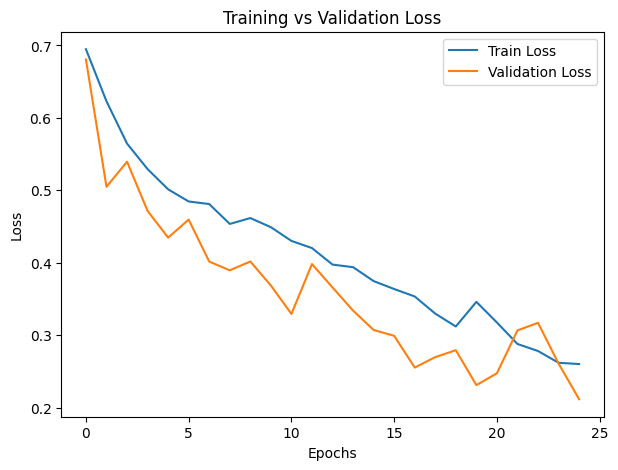


✅ All evaluation visuals generated successfully


In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ==============================
# GET PREDICTIONS
# ==============================
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_generator.class_indices.keys())

# ==============================
# OVERALL METRICS
# ==============================
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ==============================
# CLASSIFICATION REPORT
# ==============================
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# ==============================
# BAR CHART: PRECISION / RECALL / F1
# ==============================
metrics = ["precision", "recall", "f1-score"]
values_no = [
    report[class_names[0]]["precision"],
    report[class_names[0]]["recall"],
    report[class_names[0]]["f1-score"]
]
values_yes = [
    report[class_names[1]]["precision"],
    report[class_names[1]]["recall"],
    report[class_names[1]]["f1-score"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, values_no, width, label=class_names[0])
plt.bar(x + width/2, values_yes, width, label=class_names[1])
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Class-wise Performance Metrics")
plt.legend()
plt.show()

# ==============================
# HISTOGRAM: PREDICTION CONFIDENCE
# ==============================
confidence_scores = np.max(y_pred_probs, axis=1)

plt.figure(figsize=(7,5))
plt.hist(confidence_scores, bins=20)
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.title("Histogram of Prediction Confidence")
plt.show()

# ==============================
# LINE CHART: TRAINING HISTORY
# ==============================
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

print("\n✅ All evaluation visuals generated successfully")


# Testing

Saving y0.jpg to y0.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


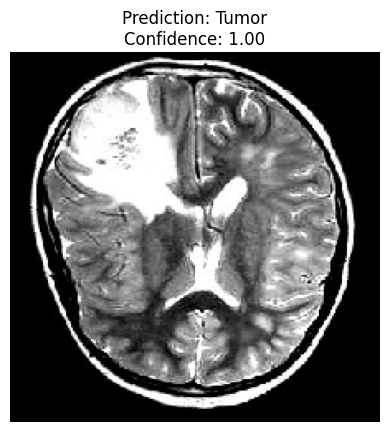

In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==============================
# PREDICTION FUNCTION
# ==============================
def predict_ct_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    class_names = list(test_generator.class_indices.keys())
    predicted_label = class_names[class_index]

    return img, predicted_label, confidence

# ==============================
# UPLOAD IMAGE(S)
# ==============================
uploaded = files.upload()

# ==============================
# DISPLAY RESULT
# ==============================
for file_name in uploaded.keys():
    img, label, confidence = predict_ct_image(file_name)

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}")
    plt.show()



Upload an image for prediction or type 'exit' to stop.


Saving no0.jpg to no0.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


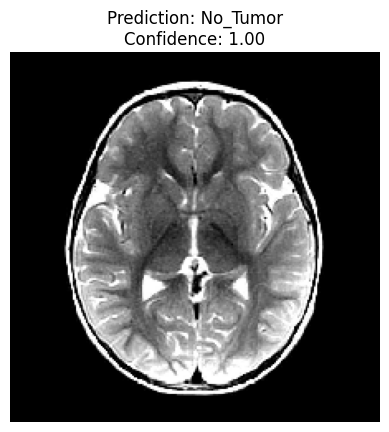

Do you want to predict another image? (yes/no): yes

Upload an image for prediction or type 'exit' to stop.


Saving y5.jpg to y5.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


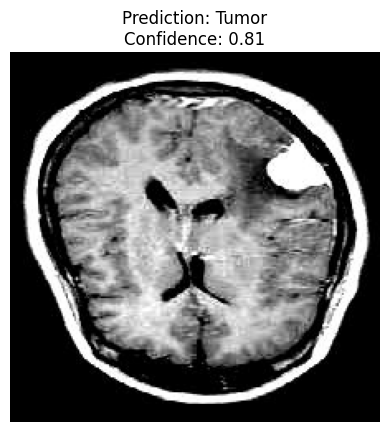

Do you want to predict another image? (yes/no): yes

Upload an image for prediction or type 'exit' to stop.


Saving y8.jpg to y8.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


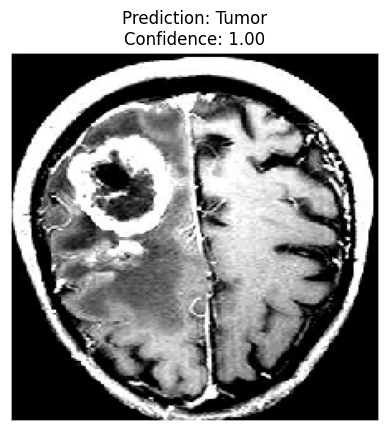

Do you want to predict another image? (yes/no): yes

Upload an image for prediction or type 'exit' to stop.


Saving no5.jpg to no5 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


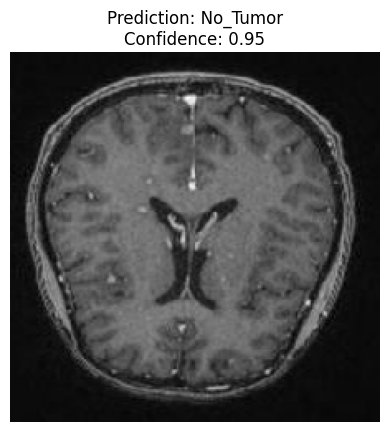

Do you want to predict another image? (yes/no): yes

Upload an image for prediction or type 'exit' to stop.


Saving no8.jpg to no8.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


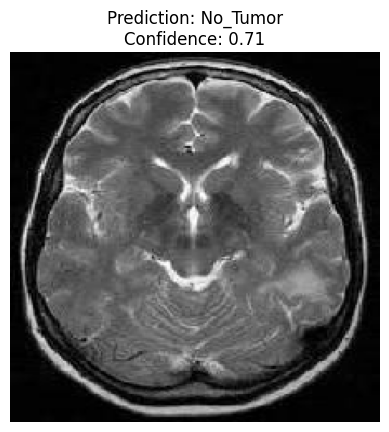

Do you want to predict another image? (yes/no): yes

Upload an image for prediction or type 'exit' to stop.


Saving y9.jpg to y9.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


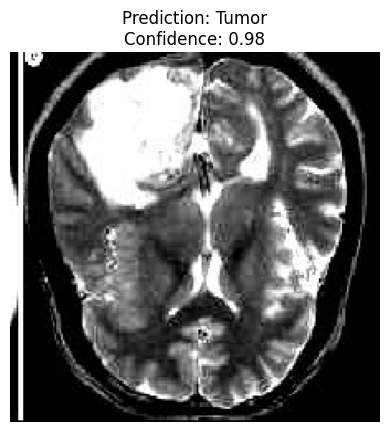

Do you want to predict another image? (yes/no): no
Exiting the program...


In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==============================
# PREDICTION FUNCTION
# ==============================
def predict_ct_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    class_names = list(test_generator.class_indices.keys())
    predicted_label = class_names[class_index]

    return img, predicted_label, confidence

# ==============================
# INTERACTIVE LOOP FOR MULTIPLE IMAGES
# ==============================
while True:
    print("\nUpload an image for prediction or type 'exit' to stop.")

    uploaded = files.upload()

    # Check if user wants to exit
    if not uploaded:
        print("No file uploaded. Exiting...")
        break

    for file_name in uploaded.keys():
        if file_name.lower() == "exit":
            print("Exiting the program...")
            exit()

        img, label, confidence = predict_ct_image(file_name)

        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}")
        plt.show()

    # Ask user if they want to continue
    user_input = input("Do you want to predict another image? (yes/no): ").strip().lower()
    if user_input not in ["yes", "y"]:
        print("Exiting the program...")
        break
